# ML Project
## Problem and Dataset Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/cardio_train.csv', sep=';')
display(df.head())
display(df.info())
display(df.describe())

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


None

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


## Data Cleaning and Pre-processing

In [2]:
# Check for missing values
print(df.isnull().sum())
if 'id' in df.columns:
    df = df.drop('id', axis=1)
df['age'] = (df['age'] / 365).round().astype(int)

df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 200)]
df = df[(df['ap_hi'] >= 60) & (df['ap_hi'] <= 240)]

df = df[(df['height'] >= 100) & (df['height'] <= 250)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

print({df.shape})

X = df.drop('cardio', axis=1)
y = df['cardio']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
display(X_scaled.head())


id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64
{(68743, 12)}


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
0,-0.491623,1.366615,0.451286,-0.847414,-0.991213,-0.142876,-0.537258,-0.39522,-0.31062,-0.238064,0.494707
1,0.247218,-0.731735,-1.051451,0.760247,0.798336,0.890523,2.408052,-0.39522,-0.31062,-0.238064,0.494707
2,-0.196086,-0.731735,0.075602,-0.707617,0.201820,-1.176275,2.408052,-0.39522,-0.31062,-0.238064,-2.021397
3,-0.787160,1.366615,0.576514,0.550552,1.394853,1.923921,-0.537258,-0.39522,-0.31062,-0.238064,0.494707
4,-0.787160,-0.731735,-1.051451,-1.266804,-1.587729,-2.209673,-0.537258,-0.39522,-0.31062,-0.238064,-2.021397


## EDA

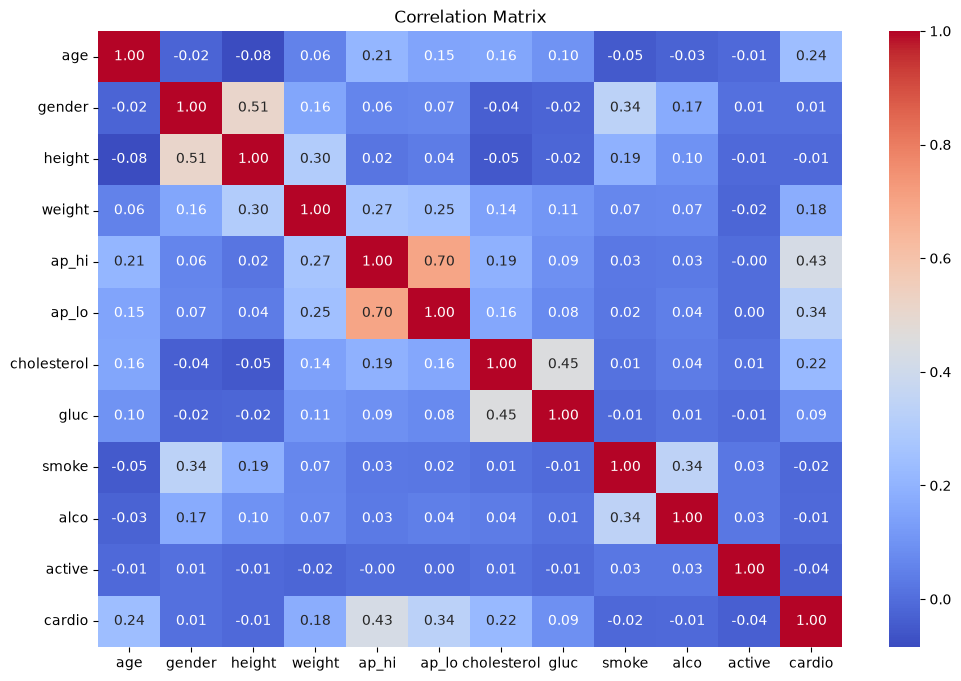

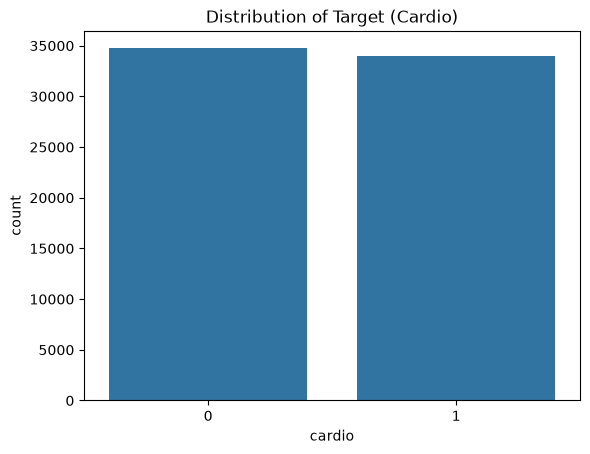

In [3]:
# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()
sns.countplot(x='cardio', data=df)
plt.title('Distribution of Target (Cardio)')
plt.show()

## Model
We will use Logistic Regression and Random Forest from `sklearn`.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)


## Scratch

In [5]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.cost_history = []

    def sigmoid(self, z):
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Gradient Descent
        for _ in range(self.epochs):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)
            
            # Gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(linear_model)
        y_predicted_cls = [1 if i > 0.5 else 0 for i in y_predicted]
        return np.array(y_predicted_cls)

scratch_model = LogisticRegressionScratch(learning_rate=0.1, epochs=1000)
scratch_model.fit(X_train.values, y_train.values)
y_pred_scratch = scratch_model.predict(X_test.values)


In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(classification_report(y_test, y_pred_log))

print("\nLogistic Regression(From Scratch)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_scratch):.4f}")
print(classification_report(y_test, y_pred_scratch))



Logistic Regression
Accuracy: 0.7306
              precision    recall  f1-score   support

           0       0.71      0.78      0.75      6929
           1       0.76      0.68      0.71      6820

    accuracy                           0.73     13749
   macro avg       0.73      0.73      0.73     13749
weighted avg       0.73      0.73      0.73     13749


Logistic Regression(From Scratch)
Accuracy: 0.7307
              precision    recall  f1-score   support

           0       0.71      0.78      0.75      6929
           1       0.76      0.68      0.71      6820

    accuracy                           0.73     13749
   macro avg       0.73      0.73      0.73     13749
weighted avg       0.73      0.73      0.73     13749



## Save Model

In [7]:
import joblib
import os

joblib.dump(scaler, '../backend/models/preprocessor.pkl')
joblib.dump(log_reg, '../backend/models/model.pkl')

['../backend/models/model.pkl']